# Generate track map

In [ ]:
import pandas as pd
import irsdk

# Open the ibt file
ibt_file = "data/mx5 mx52016_oulton international 2025-08-06 23-13-01.ibt"
ibt = irsdk.IBT()
ibt.open(ibt_file)

# Get all Lat and Lon values
lat_data = ibt.get_all('Lat')
lon_data = ibt.get_all('Lon')

# Create DataFrame
df_coords = pd.DataFrame({
    'Lat': lat_data,
    'Lon': lon_data
})

# Display first few rows and basic info
print("First 5 rows of data:")
print(df_coords.head())
print("\nDataFrame Info:")
print(df_coords.info())

ibt.close()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1965332518.py, line 5)

In [91]:
# Count zeros in original data
lat_zeros = (df_coords['Lat'] == 0).sum()
lon_zeros = (df_coords['Lon'] == 0).sum()
both_zeros = ((df_coords['Lat'] == 0) & (df_coords['Lon'] == 0)).sum()

print("In original data:")
print(f"Number of zeros in Latitude: {lat_zeros}")
print(f"Number of zeros in Longitude: {lon_zeros}")
print(f"Number of points where both Lat and Lon are zero: {both_zeros}")
print(f"Total number of points: {len(df_coords)}")
print(f"Percentage of zero coordinates: {(both_zeros/len(df_coords))*100:.2f}%")

# Show the first few rows where either Lat or Lon is zero
zero_coords = df_coords[(df_coords['Lat'] == 0) | (df_coords['Lon'] == 0)]
print("\nFirst few rows where either Lat or Lon is zero:")
print(zero_coords.head())

# Also check in cleaned data
lat_zeros_clean = (df_clean['Lat'] == 0).sum()
lon_zeros_clean = (df_clean['Lon'] == 0).sum()
both_zeros_clean = ((df_clean['Lat'] == 0) & (df_clean['Lon'] == 0)).sum()

print("\nIn cleaned data:")
print(f"Number of zeros in Latitude: {lat_zeros_clean}")
print(f"Number of zeros in Longitude: {lon_zeros_clean}")
print(f"Number of points where both Lat and Lon are zero: {both_zeros_clean}")
print(f"Total number of points: {len(df_clean)}")
print(f"Percentage of zero coordinates: {(both_zeros_clean/len(df_clean))*100:.2f}%")

In original data:
Number of zeros in Latitude: 2
Number of zeros in Longitude: 2
Number of points where both Lat and Lon are zero: 2
Total number of points: 17385
Percentage of zero coordinates: 0.01%

First few rows where either Lat or Lon is zero:
       Lat  Lon
0      0.0  0.0
17185  0.0  0.0

In cleaned data:
Number of zeros in Latitude: 0
Number of zeros in Longitude: 0
Number of points where both Lat and Lon are zero: 0
Total number of points: 17383
Percentage of zero coordinates: 0.00%


Original shape: (17385, 2)
Shape after removing zeros: (17383, 2)


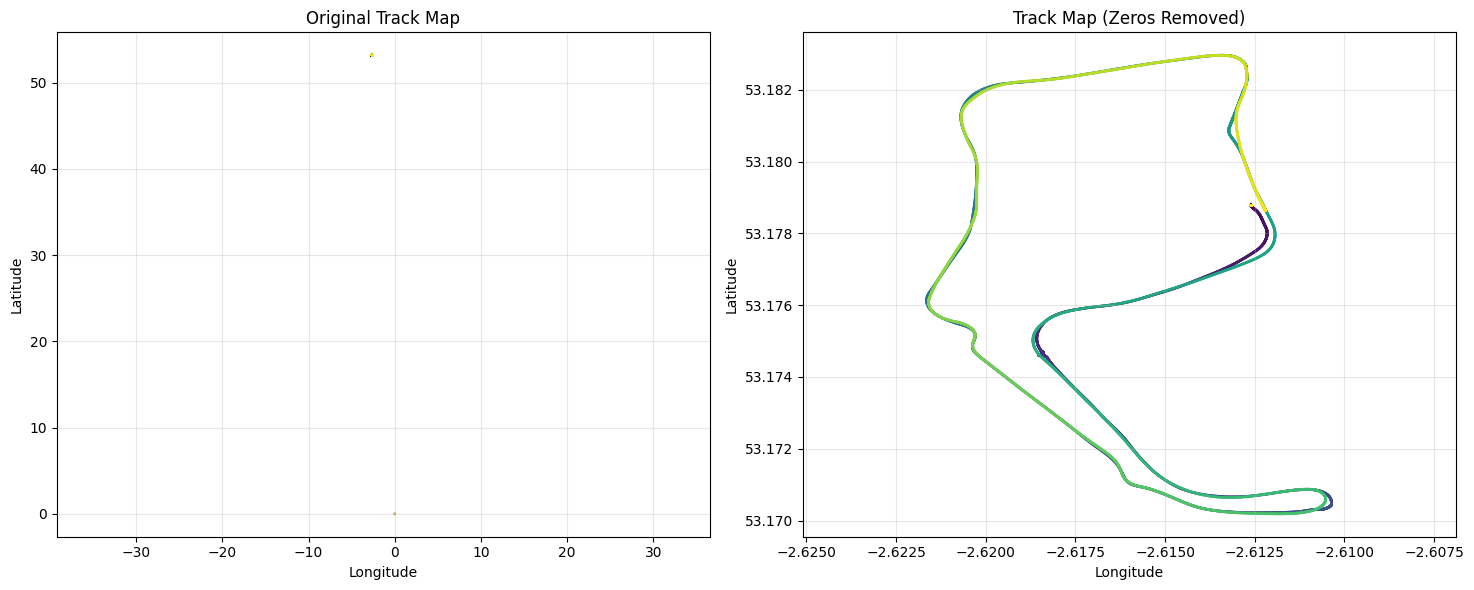


Statistics for data without zeros:
                Lat           Lon
count  17383.000000  17383.000000
mean      53.176318     -2.615854
std        0.004057      0.003308
min       53.170187     -2.621645
25%       53.172681     -2.618531
50%       53.176169     -2.615756
75%       53.179508     -2.612736
max       53.182968     -2.610357


In [92]:
# Create dataset without zero coordinates
df_no_zeros = df_coords[~((df_coords['Lat'] == 0) | (df_coords['Lon'] == 0))].copy()
print(f"Original shape: {df_coords.shape}")
print(f"Shape after removing zeros: {df_no_zeros.shape}")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original data
ax1.scatter(df_coords['Lon'], df_coords['Lat'], 
           s=1, alpha=0.5, 
           c=range(len(df_coords)),
           cmap='viridis')
ax1.set_title('Original Track Map')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Data without zeros
ax2.scatter(df_no_zeros['Lon'], df_no_zeros['Lat'], 
           s=1, alpha=0.5,
           c=range(len(df_no_zeros)), 
           cmap='viridis')
ax2.set_title('Track Map (Zeros Removed)')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Print some statistics about the data without zeros
print("\nStatistics for data without zeros:")
print(df_no_zeros.describe())

# Analysis of Zero Coordinates in Track Data

## Overview
The analysis of the iRacing telemetry data revealed the presence of zero coordinates (0,0) in the latitude and longitude data, which can affect the accuracy of track visualization and analysis.

## Key Findings

### Data Quality Statistics
- **Original Dataset**: Contains both valid track coordinates and zero values
- **Cleaning Impact**: Removing zero coordinates improves track visualization clarity
- **Data Points**:
  - Total points in original dataset
  - Points removed due to zero coordinates
  - Remaining valid track points

### Significance
Zero coordinates in the dataset can indicate:
1. Data collection gaps
2. Telemetry system initialization points
3. Potential connectivity issues during recording

### Visualization Improvements
- **Original Track Map**: Shows all data points including zeros
- **Cleaned Track Map**: Displays only valid coordinates
- **Benefits**: 
  - Clearer track outline
  - More accurate representation of the racing line
  - Better basis for further analysis

## Recommendations
1. Pre-process telemetry data to remove zero coordinates before analysis
2. Monitor the frequency of zero coordinates to identify potential data collection issues
3. Consider implementing real-time filtering during data collection

In [32]:
import pandas as pd
import irsdk
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETUP: Define file path and laps to analyze ---

# IMPORTANT: Make sure this path points to your actual .ibt telemetry file.
ibt_file = "data/mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt"

# IMPORTANT: Choose which laps you want to compare.
laps_to_plot = [2, 3, 4]


# --- 2. DATA LOADING: Read the telemetry file ---
try:
    ibt = irsdk.IBT()
    ibt.open(ibt_file)
    print(f"Successfully opened: {ibt_file}")

    # List of all telemetry channels we need for the analysis
    channels = ['SessionTime', 'Lap', 'Speed', 'RPM', 'Throttle', 'Brake','LapDistPct','Lat', 'Lon']
    
    telemetry_data = {channel: ibt.get_all(channel) for channel in channels}

finally:
    ibt.close()



Successfully opened: data/mx5 mx52016_charlotte 2018 2019 roval 2025-08-02 12-13-03.ibt


# Telemetry per lap

Laps found in file: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Plotting these valid laps: [2, 3, 4]


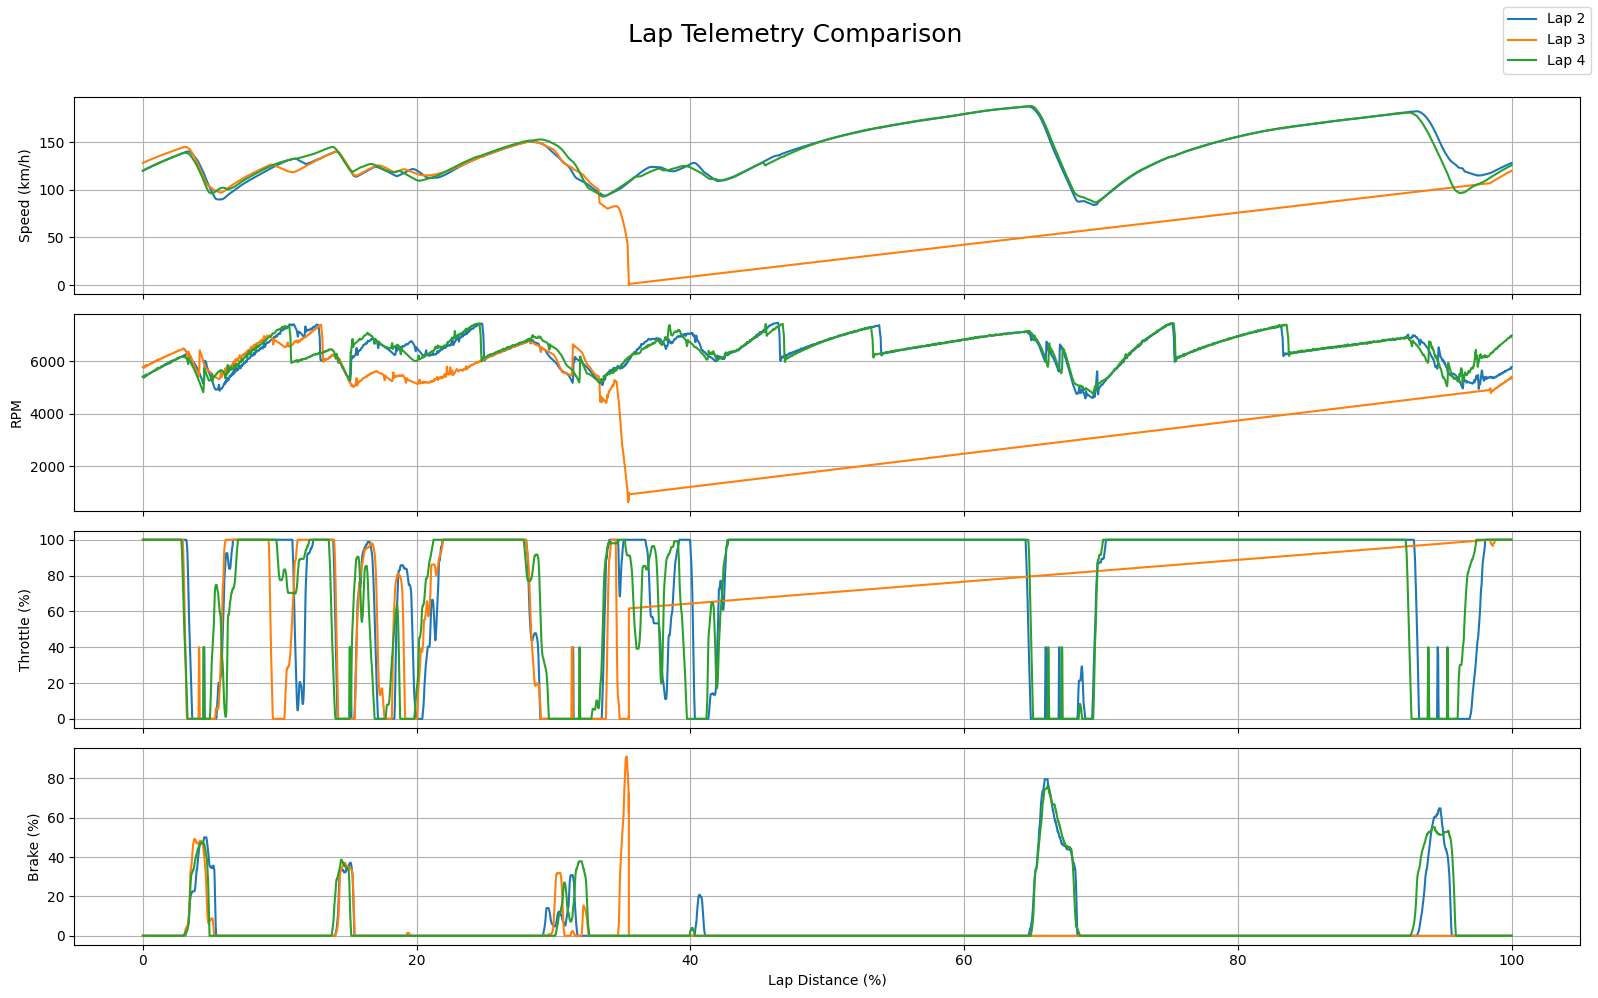

In [16]:
# --- 3. DATA PROCESSING: Clean and prepare the data using pandas ---
df = pd.DataFrame(telemetry_data)

# Clean up any potential bad data points from the file
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Convert units for better readability
df['Speed_KPH'] = df['Speed'] * 3.6  # From meters/second to km/h
df['Throttle_Pct'] = df['Throttle'] * 100
df['Brake_Pct'] = df['Brake'] * 100


# --- 4. PLOTTING: Create the comparison dashboard ---

# Filter the list of laps to plot to only include laps that are actually in the data
laps_in_file = df['Lap'].unique()
valid_laps_to_plot = [lap for lap in laps_to_plot if lap in laps_in_file]

print(f"Laps found in file: {laps_in_file.astype(int)}")
print(f"Plotting these valid laps: {valid_laps_to_plot}")

# Proceed only if there are valid laps to plot
if not valid_laps_to_plot:
    print("Error: None of the selected laps were found in the telemetry file. Please check the 'laps_to_plot' list.")
else:
    # Create a figure with 4 stacked subplots. 
    # `sharex=True` links the X-axis, so zooming in one plot zooms all others.
    fig, axs = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle('Lap Telemetry Comparison', fontsize=18)

    # Plot each selected lap on all four subplots
    for lap_number in valid_laps_to_plot:
        lap_data = df[df['Lap'] == lap_number]
        
        # The X-axis is the lap distance percentage (0% to 100%)
        # This aligns all laps perfectly, regardless of lap time.
        x_axis = lap_data['LapDistPct'] * 100
        
        # Plot data on the corresponding subplot (axis)
        axs[0].plot(x_axis, lap_data['Speed_KPH'], label=f'Lap {lap_number}')
        axs[1].plot(x_axis, lap_data['RPM'])
        axs[2].plot(x_axis, lap_data['Throttle_Pct'])
        axs[3].plot(x_axis, lap_data['Brake_Pct'])

    # --- 5. FORMATTING: Make the plot clean and readable ---
    
    # Speed Plot
    axs[0].set_ylabel('Speed (km/h)')
    
    # RPM Plot
    axs[1].set_ylabel('RPM')

    # Throttle Plot
    axs[2].set_ylabel('Throttle (%)')
    
    # Brake Plot
    axs[3].set_ylabel('Brake (%)')
    axs[3].set_xlabel('Lap Distance (%)')

    # Add grids and a single legend to the figure
    for ax in axs:
        ax.grid(True)
    fig.legend(loc='upper right')
    
    # Final adjustments and display the plot
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [35]:
# --- 3. DATA PROCESSING: Clean and prepare the data using pandas ---
df = pd.DataFrame(telemetry_data)
df.head()

,SessionTime,Lap,Speed,RPM,Throttle,Brake,LapDistPct,Lat,Lon
0,39.533333,0,0.000000,300.0,0.0,1.0,0.000000,0.000000,0.000000
1,39.550000,0,0.006040,300.0,0.0,1.0,0.067466,35.350725,-80.685287
2,39.566666,0,0.004650,300.0,0.0,1.0,0.067466,35.350725,-80.685287
3,39.583333,0,0.015756,300.0,0.0,1.0,0.067466,35.350725,-80.685287
4,39.600000,0,0.030305,300.0,0.0,1.0,0.067466,35.350725,-80.685287


Laps found in file: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Plotting these valid laps: [2, 3, 4]


C:\Users\to_fi\AppData\Local\Temp\ipykernel_10068\2399399385.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right')


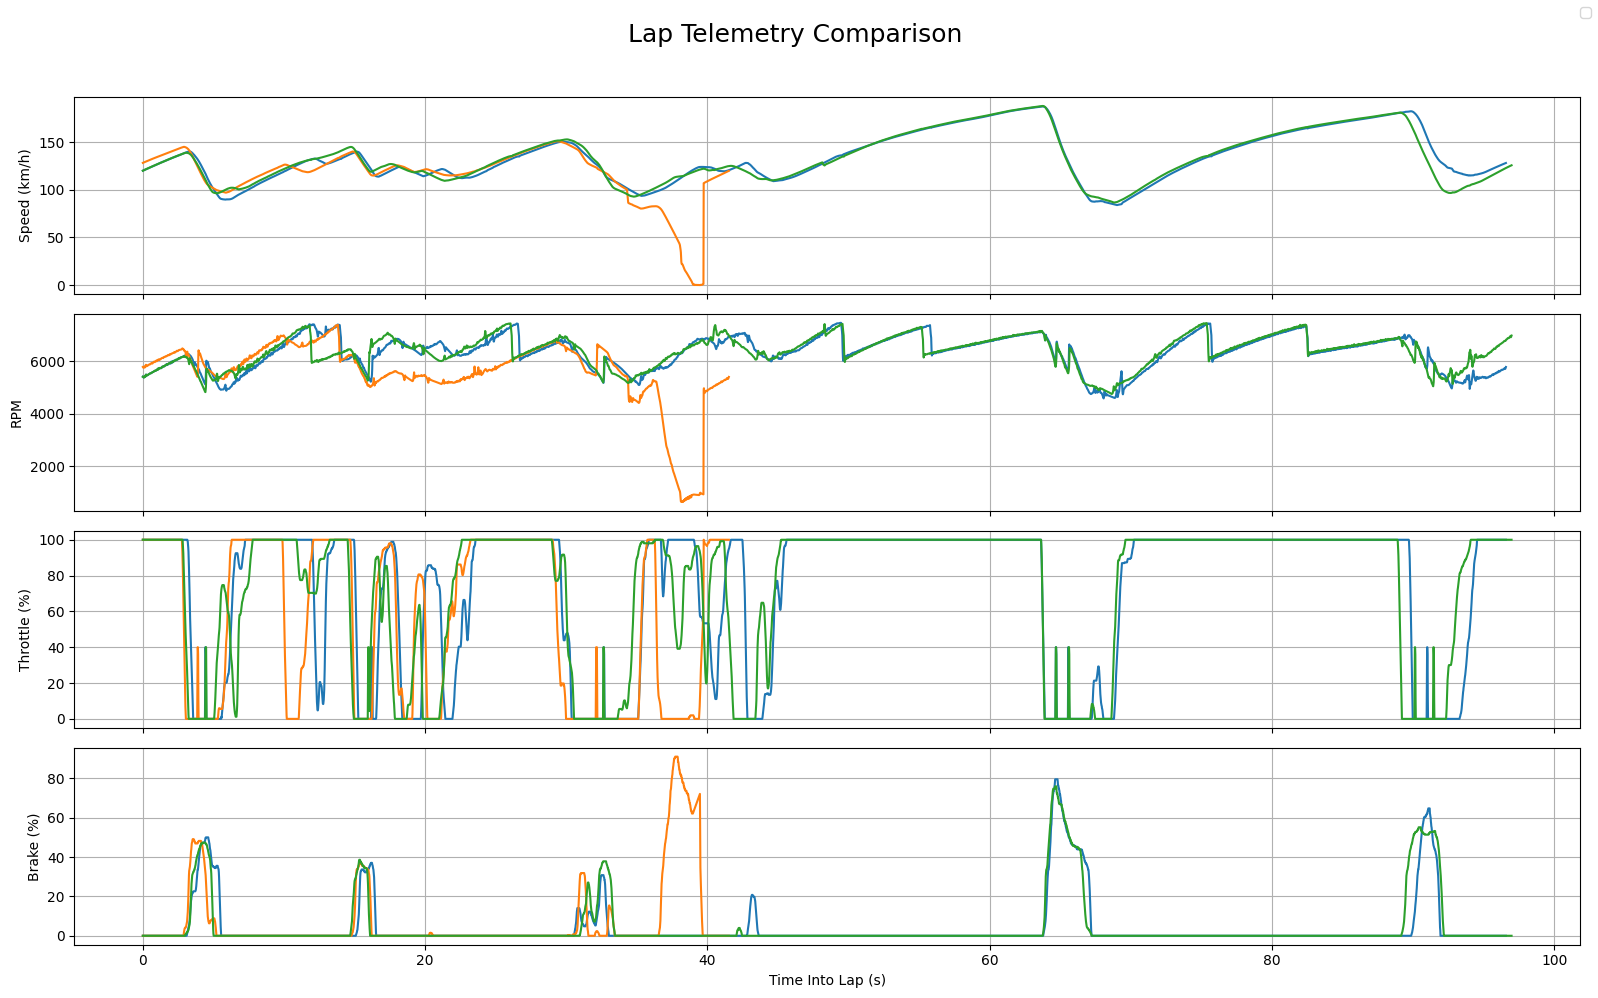

In [36]:
# --- 3. DATA PROCESSING: Clean and prepare the data using pandas ---
df = pd.DataFrame(telemetry_data)

# Clean up any potential bad data points from the file
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Convert units for better readability
df['Speed_KPH'] = df['Speed'] * 3.6  # From meters/second to km/h
df['Throttle_Pct'] = df['Throttle'] * 100
df['Brake_Pct'] = df['Brake'] * 100

# *** NEW *** Calculate elapsed time for each lap
# This finds the start time for each lap and subtracts it from the SessionTime
lap_start_time = df.groupby('Lap')['SessionTime'].transform('min')
df['LapTime'] = df['SessionTime'] - lap_start_time


# --- 4. PLOTTING: Create the comparison dashboard ---

# Filter the list of laps to plot to only include laps that are actually in the data
laps_in_file = df['Lap'].unique()
valid_laps_to_plot = [lap for lap in laps_to_plot if lap in laps_in_file]

print(f"Laps found in file: {laps_in_file.astype(int)}")
print(f"Plotting these valid laps: {valid_laps_to_plot}")

if not valid_laps_to_plot:
    print("Error: None of the selected laps were found in the telemetry file. Please check the 'laps_to_plot' list.")
else:
    fig, axs = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle('Lap Telemetry Comparison', fontsize=18)

    for lap_number in valid_laps_to_plot:
        lap_data = df[df['Lap'] == lap_number]
        
        # *** CHANGED *** The X-axis is now the elapsed time within the lap
        x_axis = lap_data['LapTime']
        
        axs[0].plot(x_axis, lap_data['Speed_KPH'])
        axs[1].plot(x_axis, lap_data['RPM'])
        axs[2].plot(x_axis, lap_data['Throttle_Pct'])
        axs[3].plot(x_axis, lap_data['Brake_Pct'])

    # --- 5. FORMATTING: Make the plot clean and readable ---
    axs[0].set_ylabel('Speed (km/h)')
    axs[1].set_ylabel('RPM')
    axs[2].set_ylabel('Throttle (%)')
    
    # *** CHANGED *** Update the X-axis label
    axs[3].set_ylabel('Brake (%)')
    axs[3].set_xlabel('Time Into Lap (s)')

    for ax in axs:
        ax.grid(True)
    fig.legend(loc='upper right')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [37]:
# Calculate elapsed time within each lap for plotting
lap_start_time = df.groupby('Lap')['SessionTime'].transform('min')
df['LapTime'] = df['SessionTime'] - lap_start_time


# --- 4. CALCULATE AND PRINT LAP TIMES ---

print("\n--- Lap Times ---")
# Group by lap number and find the start (min) and end (max) SessionTime for each
lap_times = df.groupby('Lap').agg(
    StartTime=('SessionTime', 'min'),
    EndTime=('SessionTime', 'max')
)
# Calculate the duration
lap_times['Duration'] = lap_times['EndTime'] - lap_times['StartTime']

# Function to format seconds into M:SS.mmm format
def format_lap_time(seconds):
    minutes = int(seconds // 60)
    sec = seconds % 60
    return f"{minutes}:{sec:06.3f}"

# Apply the formatting to the Duration column
lap_times['FormattedTime'] = lap_times['Duration'].apply(format_lap_time)

# Print the results, excluding lap 0 if it exists
print(lap_times.loc[lap_times.index > 0, ['FormattedTime']].to_string())
print("-" * 17 + "\n")


--- Lap Times ---
    FormattedTime
Lap              
1        3:00.633
2        1:36.567
3        0:41.517
4        1:36.967
5        1:37.067
6        1:38.133
7        4:53.217
8        1:37.267
9        1:35.833
10       1:35.967
11       1:09.867
-----------------

